# Complete TFM analysis: Iberian intraday supply and demand curves

This notebook contains the full empirical workflow used in the thesis. It downloads or loads OMIE intraday auction curve files, constructs Iberian supply and demand curves, approximates them on a common empirical price grid, applies standard KMeans clustering, and characterizes the final clusters using temporal and ENTSO-E system variables.

The workflow is organized in the order of the analysis: data collection, preprocessing, curve construction, grid approximation, clustering, visualization, and Random Forest characterization.

In [2]:
# ============================================================
# 0. Imports and settings
# ============================================================

import os
import re
import warnings
from pathlib import Path
from datetime import date
import requests
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.inspection import permutation_importance

from entsoe import EntsoePandasClient

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# Main thesis settings
# ------------------------------------------------------------

# Folder used for raw OMIE curva_pibc files.
folder = Path("data_raw_omie")

# Set to True to download OMIE files.
# Set to False if the files are already available in the folder above.
RUN_OMIE_DOWNLOAD = True

# Time interval
START_DATE = date(2025, 3, 20)
END_DATE = date(2026, 3, 20)
OMIE_SESSIONS = [1, 2, 3]

# Grid and clustering settings
candidate_G_values = [50, 100, 150, 200]
final_G = 150
FINAL_G = 150
NORMALIZE_CURVES = False

M_reference = 2000
random_seed = 42
RANDOM_SEED = 42

# Grid-error computation uses all curves by default.
# Use a smaller number while testing if needed.
max_curves_for_error = None

# ENTSO-E API token for the Random Forest section.
ENTSOE_API_TOKEN_MANUAL = ""

# Output folders
Path("figures").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)
Path("chapter7_rf_entsoe").mkdir(exist_ok=True)
folder.mkdir(parents=True, exist_ok=True)

print("Imports and settings loaded.")

/Users/mikeknecht/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports and settings loaded.


## 1. OMIE data download and parsing

This section gets the OMIE intraday auction curve files. If `RUN_OMIE_DOWNLOAD` is set to `True`, the notebook tries to download all available files for the selected date range and sessions. If it is set to `False`, it uses the files already stored in `data_raw_omie`.

The following cells also parse the raw OMIE files into one bid-level dataframe called `bids`.

In [3]:
# ============================================================
# 1.1 Download or load OMIE files
# ============================================================

OMIE_BASE = "https://www.omie.es"
FILENAME_RE = re.compile(r"^curva_pibc_(\d{8})(\d{1,2})\.1$")


# Extract date and intraday auction session from an OMIE filename.
def parse_file_key(file_path):
    m = FILENAME_RE.match(Path(file_path).name)

    if m is None:
        return None

    return m.group(1), int(m.group(2))


def deduplicate_files(files):
    """
    Keep one file per date-session. If both one and two digit session filenames exist, keep the two digit version.
    """
    deduped = {}

    for f in files:
        key = parse_file_key(f)

        if key is None:
            continue

        if key not in deduped:
            deduped[key] = Path(f)
        else:
            old_session = FILENAME_RE.match(deduped[key].name).group(2)
            new_session = FILENAME_RE.match(Path(f).name).group(2)

            if len(new_session) > len(old_session):
                deduped[key] = Path(f)

    return sorted(deduped.values())


# Download all available OMIE files for the selected dates and sessions.
def download_omie_files(start_date, end_date, sessions, folder):
    folder.mkdir(parents=True, exist_ok=True)

    tasks = [
        (day, session)
        for day in pd.date_range(start_date, end_date, freq="D")
        for session in sessions
    ]

    downloaded = 0
    existing = 0

    with requests.Session() as s:
        for day, session in tqdm(tasks, desc="Downloading OMIE files", unit="file"):
            ymd = day.strftime("%Y%m%d")

            filenames = [
                f"curva_pibc_{ymd}{session:02d}.1",
                f"curva_pibc_{ymd}{session}.1",
            ]

            for filename in filenames:
                path = folder / filename

                if path.exists():
                    existing += 1
                    break

                url = f"{OMIE_BASE}/en/file-download?filename={filename}&parents=curva_pibc"
                r = s.get(url, timeout=60)

                if r.status_code == 200 and b"<html" not in r.content[:200].lower():
                    path.write_bytes(r.content)
                    downloaded += 1
                    break

    files = deduplicate_files(sorted(folder.glob("curva_pibc_*")))

    print("Downloaded now:", downloaded)
    print("Already existing:", existing)
    print("Usable OMIE files:", len(files))

    return files


if RUN_OMIE_DOWNLOAD:
    omie_files = download_omie_files(
        START_DATE,
        END_DATE,
        OMIE_SESSIONS,
        folder,
    )
else:
    print("Using local OMIE files from:", folder)
    omie_files = deduplicate_files(sorted(folder.glob("curva_pibc_*")))

print("OMIE files available for analysis:", len(omie_files))

if len(omie_files) == 0:
    raise FileNotFoundError("No OMIE files available.")

Downloaded now: 0
Already existing: 1070
Usable OMIE files: 1070
OMIE files available for analysis: 1070


In [4]:
# ============================================================
# 1.2 Parse OMIE files into one bid-level dataframe
# ============================================================

# Read one OMIE file, standardize column names, clean numbers, and keep only buy/sell bid rows.
def read_omie_file(file_path):
    df = pd.read_csv(
        file_path,
        sep=";",
        encoding="latin-1",
        skiprows=2,
        engine="python",
    )

    df = df.dropna(axis=1, how="all")

    if len(df.columns) == 8:
        df.columns = [
            "period",
            "date",
            "country",
            "offer_type",
            "quantity",
            "price",
            "offer_status",
            "offer_typology",
        ]

    elif len(df.columns) == 9:
        df.columns = [
            "period",
            "date",
            "country",
            "unit",
            "offer_type",
            "quantity",
            "price",
            "offer_status",
            "offer_typology",
        ]

    else:
        raise ValueError(
            f"Unexpected number of columns in {file_path.name}: {len(df.columns)}"
        )

    # Keep only the columns needed later
    df = df[[
        "period",
        "date",
        "country",
        "offer_type",
        "quantity",
        "price",
    ]].copy()

    # Clean text columns
    for col in ["period", "date", "country", "offer_type"]:
        df[col] = df[col].astype(str).str.strip()

    # Convert number format to float
    for col in ["quantity", "price"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Keep valid buy/sell rows only
    df = df.dropna(subset=["period", "date", "country", "offer_type", "quantity", "price"])
    df = df[df["offer_type"].isin(["C", "V"])].copy()

    # C = buy/demand, V = sell/supply
    df["offer_type"] = df["offer_type"].map({
        "C": "buy",
        "V": "sell",
    })

    # Add file-level metadata
    file_key = parse_file_key(file_path)

    df["file"] = file_path.name
    df["file_date"] = file_key[0] if file_key is not None else None
    df["session"] = file_key[1] if file_key is not None else np.nan

    return df[[
        "file",
        "file_date",
        "session",
        "date",
        "period",
        "country",
        "offer_type",
        "quantity",
        "price",
    ]]


# Combine all parsed OMIE files into one dataframe.
def parse_omie_files(files):
    chunks = []

    for file_path in tqdm(files, desc="Parsing OMIE files", unit="file"):
        chunks.append(read_omie_file(file_path))

    return pd.concat(chunks, ignore_index=True)


bids = parse_omie_files(omie_files)

print("OMIE bid data ready.")
print("Rows:", len(bids))
print("Files:", len(omie_files))

Parsing OMIE files: 100%|██████████| 1070/1070 [07:01<00:00,  2.54file/s]


OMIE bid data ready.
Rows: 202738347
Files: 1070


## 2. Descriptive statistics

This section summarizes bid prices and bid volumes separately for buy and sell offers.

In [5]:
# ============================================================
# 2. Descriptive statistics of bid prices and volumes
# ============================================================

def describe_series(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "N": 0,
            "Min": np.nan,
            "Max": np.nan,
            "Mean": np.nan,
            "Median": np.nan,
            "Std. Deviation": np.nan,
        }

    return {
        "N": len(x),
        "Min": np.min(x),
        "Max": np.max(x),
        "Mean": np.mean(x),
        "Median": np.percentile(x, 50),
        "Std. Deviation": np.std(x, ddof=1),
    }


buy_rows = bids[bids["offer_type"] == "buy"]
sell_rows = bids[bids["offer_type"] == "sell"]

buy_prices = buy_rows["price"]
sell_prices = sell_rows["price"]
buy_volumes = buy_rows["quantity"]
sell_volumes = sell_rows["quantity"]

stats = pd.DataFrame({
    "Buy price": describe_series(buy_prices),
    "Sell price": describe_series(sell_prices),
    "Buy volume": describe_series(buy_volumes),
    "Sell volume": describe_series(sell_volumes),
}).T

display(stats.round(2))

,N,Min,Max,Mean,Median,Std. Deviation
Buy price,103559043.0,-9999.00,4216.3,166.31,113.42,165.14
Sell price,99179304.0,-1259.96,3432.0,19.93,0.00,75.22
Buy volume,103559043.0,0.10,5623.4,6.03,0.70,25.48
Sell volume,99179304.0,0.10,4451.4,8.38,0.90,35.30


## 3. Price and volume distributions

This figure shows the empirical distributions of bid prices and bid volumes for buy and sell offers.

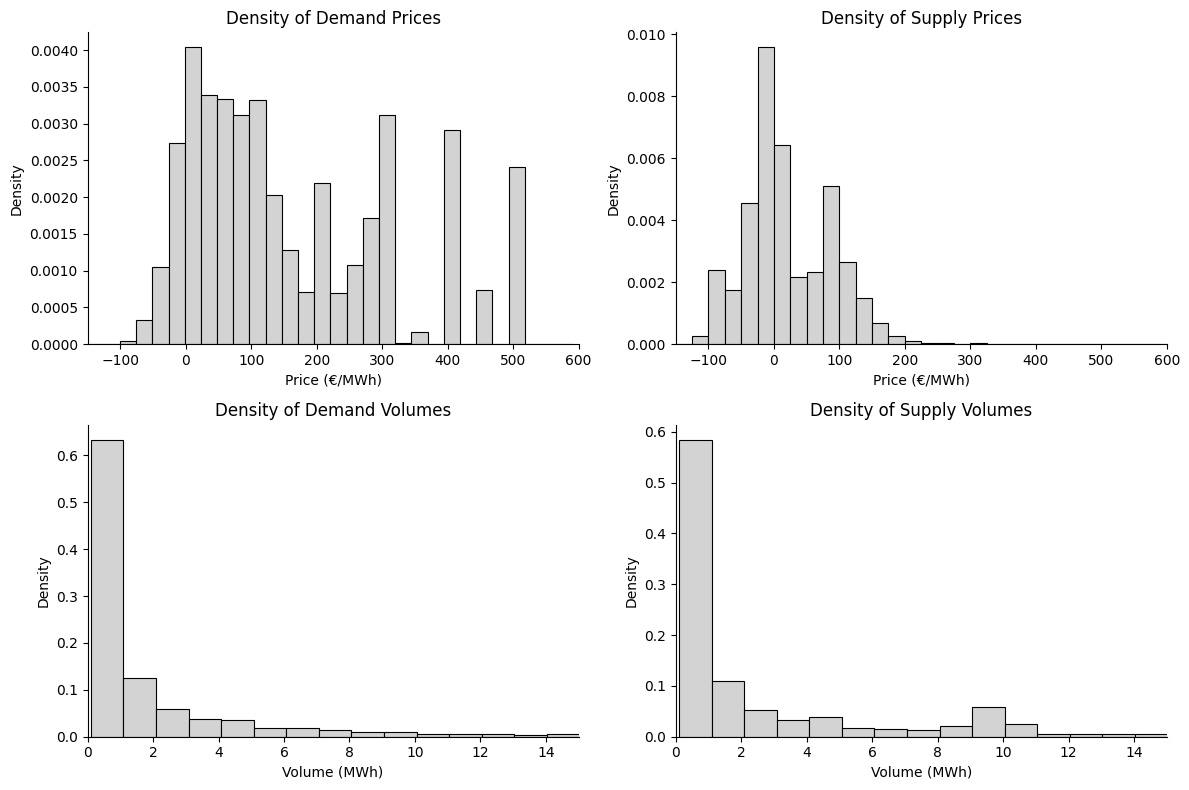

Saved: figures/histograms_bid_prices_volumes.png


In [6]:
# ============================================================
# 3. Plot bid-price and bid-volume distributions
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Demand prices
x = pd.to_numeric(buy_prices, errors="coerce").dropna().to_numpy()
x = x[np.isfinite(x)]
x = x[(x >= -150) & (x <= 600)]
axes[0, 0].hist(x, bins=30, density=True, facecolor="lightgray", edgecolor="black", linewidth=0.8)
axes[0, 0].set_title("Density of Demand Prices")
axes[0, 0].set_xlabel("Price (€/MWh)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_xlim(-150, 600)

# Supply prices
x = pd.to_numeric(sell_prices, errors="coerce").dropna().to_numpy()
x = x[np.isfinite(x)]
x = x[(x >= -150) & (x <= 600)]
axes[0, 1].hist(x, bins=30, density=True, facecolor="lightgray", edgecolor="black", linewidth=0.8)
axes[0, 1].set_title("Density of Supply Prices")
axes[0, 1].set_xlabel("Price (€/MWh)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_xlim(-150, 600)

# Demand volumes
x = pd.to_numeric(buy_volumes, errors="coerce").dropna().to_numpy()
x = x[np.isfinite(x)]
x = x[(x >= 0) & (x <= 20)]
axes[1, 0].hist(x, bins=20, density=True, facecolor="lightgray", edgecolor="black", linewidth=0.8)
axes[1, 0].set_title("Density of Demand Volumes")
axes[1, 0].set_xlabel("Volume (MWh)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlim(0, 15)

# Supply volumes
x = pd.to_numeric(sell_volumes, errors="coerce").dropna().to_numpy()
x = x[np.isfinite(x)]
x = x[(x >= 0) & (x <= 20)]
axes[1, 1].hist(x, bins=20, density=True, facecolor="lightgray", edgecolor="black", linewidth=0.8)
axes[1, 1].set_title("Density of Supply Volumes")
axes[1, 1].set_xlabel("Volume (MWh)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_xlim(0, 15)

for ax in axes.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

plt.tight_layout()
plt.savefig("figures/histograms_bid_prices_volumes.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/histograms_bid_prices_volumes.png")

## 4. Curve construction and empirical price grid

This section aggregates the bid-level data into one Iberian supply-demand curve pair per file, delivery date, session, and period. If both Spanish and Portuguese market areas (`ES` and `PT`) are available, they are aggregated into a synthetic Iberian curve. Otherwise, the integrated market identifier (`MI`) is used.

The curves are then evaluated on a common empirical price grid. This creates the matrix used for KMeans clustering.

Constructing Iberian curves: 100%|██████████| 85139/85139 [02:02<00:00, 693.37group/s]


Constructed curve pairs: 85139
Final grid nodes: 150


Grid error G=200: 100%|██████████| 85139/85139 [00:08<00:00, 10088.97it/s]


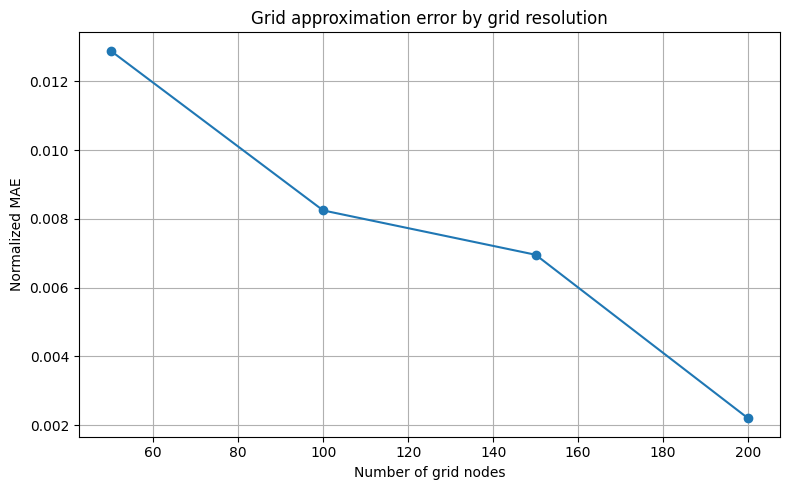

Building X matrix: 100%|██████████| 85139/85139 [00:01<00:00, 43824.50it/s]


X shape: (85139, 300)


In [7]:
# ============================================================
# 4. Construct curves, empirical grid, and grid-resolution plot
# ============================================================

# Aggregate bid blocks by price to form one side of a step curve.
def aggregate_curve(group, side):
    g = (
        group[group["offer_type"] == side]
        .groupby("price", as_index=False)["quantity"]
        .sum()
        .sort_values("price")
    )

    if len(g) < 2:
        return None

    return {
        "prices": g["price"].to_numpy(float),
        "quantities": g["quantity"].to_numpy(float),
    }


# Evaluate a supply or demand step curve on a given price grid.
def evaluate_curve(curve, x, side):
    prices = curve["prices"]
    quantities = curve["quantities"]
    x = np.asarray(x)

    if side == "supply":
        cumulative = np.concatenate([[0.0], np.cumsum(quantities)])
        idx = np.searchsorted(prices, x, side="right")
        return cumulative[idx]

    if side == "demand":
        cumulative = np.concatenate([np.cumsum(quantities[::-1])[::-1], [0.0]])
        idx = np.searchsorted(prices, x, side="left")
        return cumulative[idx]


# Build a non-uniform empirical grid from observed bid-price quantiles.
def make_empirical_grid(prices, G):
    prices = pd.Series(prices).dropna().to_numpy(float)
    prices = prices[np.isfinite(prices)]

    return np.unique(np.quantile(prices, np.linspace(0, 1, G)))


# Compare a grid approximation with the original curve on a dense reference grid.
def grid_error(curve, side, grid, reference_grid):
    original = evaluate_curve(curve, reference_grid, side)
    grid_values = evaluate_curve(curve, grid, side)

    idx = np.searchsorted(grid, reference_grid, side="right") - 1
    idx = np.clip(idx, 0, len(grid) - 1)

    approx = grid_values[idx]

    mae = np.mean(np.abs(original - approx))
    scale = np.max(original) - np.min(original)

    if scale <= 0 or not np.isfinite(scale):
        return np.nan

    return mae / scale


# ------------------------------------------------------------
# 4.1 Construct Iberian curve pairs
# ------------------------------------------------------------

group_cols = ["file", "file_date", "session", "date", "period"]
groups = bids.groupby(group_cols, sort=False)

curve_rows = []
all_prices = []

for key, group in tqdm(
    groups,
    total=groups.ngroups,
    desc="Constructing Iberian curves",
    unit="group",
):
    file_name, file_date, session, delivery_date, period = key
    countries = set(group["country"])
    
    # Country handling: if ES and PT are both available, aggregate them into one Iberian curve.
    # Otherwise use MI, which is already reported as an integrated Iberian market curve.

    if {"ES", "PT"}.issubset(countries):
        market_group = group[group["country"].isin(["ES", "PT"])]
        source_type = "synthetic_ES_PT"
    elif "MI" in countries:
        market_group = group[group["country"] == "MI"]
        source_type = "observed_MI"
    else:
        continue

    supply = aggregate_curve(market_group, "sell")
    demand = aggregate_curve(market_group, "buy")

    if supply is None or demand is None:
        continue

    all_prices.extend([supply["prices"], demand["prices"]])

    curve_rows.append({
        "file": file_name,
        "file_date": file_date,
        "date": delivery_date,
        "session": session,
        "period": period,
        "source_type": source_type,
        "supply": supply,
        "demand": demand,
    })

curves_df = pd.DataFrame(curve_rows)
all_prices = np.concatenate(all_prices)

print("Constructed curve pairs:", len(curves_df))


# ------------------------------------------------------------
# 4.2 Create final empirical grid
# ------------------------------------------------------------

grid = make_empirical_grid(all_prices, final_G)

print("Final grid nodes:", len(grid))


# ------------------------------------------------------------
# 4.3 Grid-resolution plot
# ------------------------------------------------------------

reference_grid = np.linspace(np.nanmin(all_prices), np.nanmax(all_prices), M_reference)

grid_results = []

for G in candidate_G_values:
    grid_G = make_empirical_grid(all_prices, G)

    supply_errors = []
    demand_errors = []

    for _, row in tqdm(
        curves_df.iterrows(),
        total=len(curves_df),
        desc=f"Grid error G={G}",
    ):
        supply_errors.append(
            grid_error(row["supply"], "supply", grid_G, reference_grid)
        )
        demand_errors.append(
            grid_error(row["demand"], "demand", grid_G, reference_grid)
        )

    grid_results.append({
        "G": len(grid_G),
        "error": np.nanmean(
            0.5 * (np.asarray(supply_errors) + np.asarray(demand_errors))
        ),
    })

grid_results = pd.DataFrame(grid_results)

plt.figure(figsize=(8, 5))
plt.plot(grid_results["G"], grid_results["error"], marker="o")
plt.xlabel("Number of grid nodes")
plt.ylabel("Normalized MAE")
plt.title("Grid approximation error by grid resolution")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/grid_resolution_error.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 4.4 Create final matrix for KMeans
# ------------------------------------------------------------

X_rows = []
meta_rows = []

for _, row in tqdm(
    curves_df.iterrows(),
    total=len(curves_df),
    desc="Building X matrix",
):
    supply_values = evaluate_curve(row["supply"], grid, "supply")
    demand_values = evaluate_curve(row["demand"], grid, "demand")

    X_rows.append(np.concatenate([supply_values, demand_values]))

    meta_rows.append({
        "file": row["file"],
        "file_date": row["file_date"],
        "date": row["date"],
        "session": row["session"],
        "period": row["period"],
        "source_type": row["source_type"],
    })

X_market = np.vstack(X_rows)
curve_meta = pd.DataFrame(meta_rows)

print("X shape:", X_market.shape)

## 5. Example grid approximations

This section illustrates how the same supply and demand curve is approximated with different grid sizes.

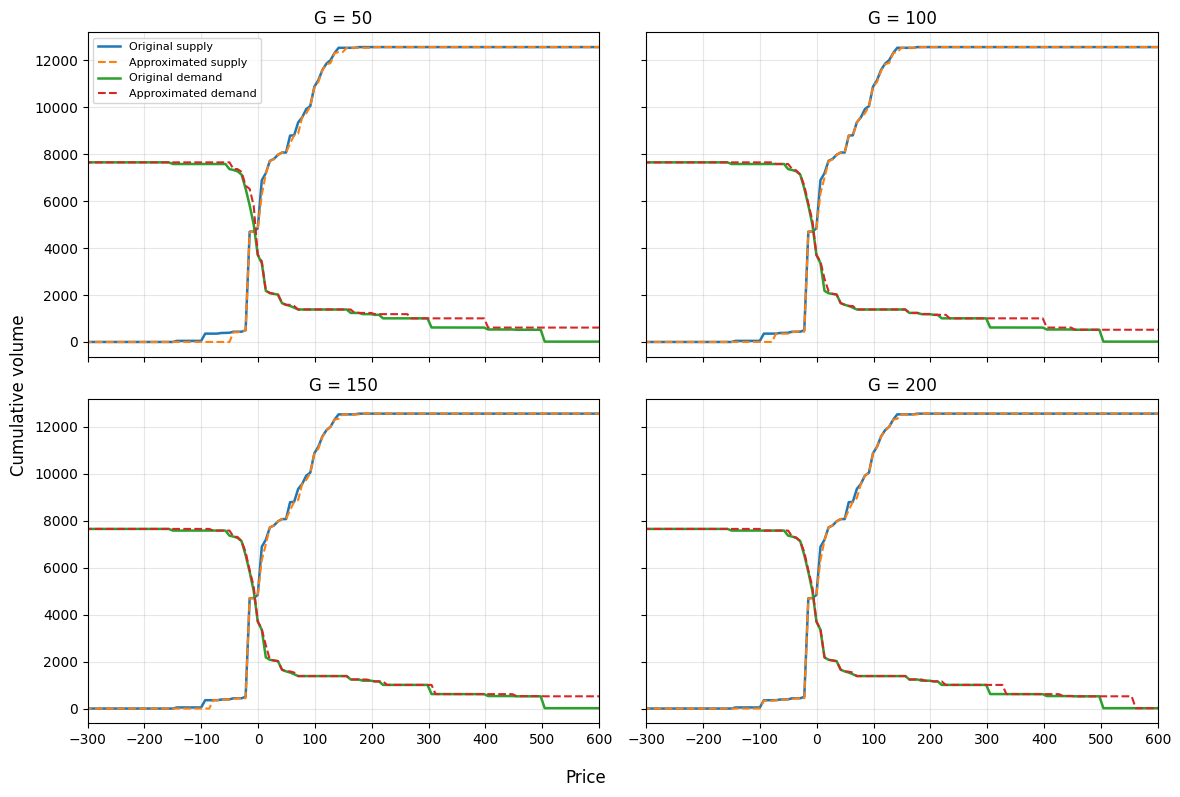

Saved: figures/grid_approximation_examples.png
file           curva_pibc_2025032001.1
date                        20/03/2025
period                            H7Q2
source_type                observed_MI
Name: 25, dtype: object


In [8]:
# ============================================================
# 5.1 Plot example grid-based approximations
# ============================================================

# Reconstruct a step approximation from values stored at grid nodes.
def step_approximation(grid, grid_values, x):
    x = np.asarray(x)
    idx = np.searchsorted(grid, x, side="right") - 1
    idx = np.clip(idx, 0, len(grid) - 1)
    return grid_values[idx]

# Select one curve pair for the example plot
example_idx = 25
example_row = curves_df.iloc[example_idx]

# Define the dense reference grid used for plotting the original curves.
reference_grid = np.linspace(np.nanmin(all_prices), np.nanmax(all_prices), M_reference)

supply_original = evaluate_curve(example_row["supply"], reference_grid, "supply")
demand_original = evaluate_curve(example_row["demand"], reference_grid, "demand")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, G_candidate in zip(axes, candidate_G_values):
    grid_candidate = make_empirical_grid(all_prices, G_candidate)

    supply_grid_values = evaluate_curve(example_row["supply"], grid_candidate, "supply")
    demand_grid_values = evaluate_curve(example_row["demand"], grid_candidate, "demand")

    supply_approx = step_approximation(grid_candidate, supply_grid_values, reference_grid)
    demand_approx = step_approximation(grid_candidate, demand_grid_values, reference_grid)

    ax.plot(reference_grid, supply_original, label="Original supply", linewidth=1.8)
    ax.plot(reference_grid, supply_approx, linestyle="--", label="Approximated supply")
    ax.plot(reference_grid, demand_original, label="Original demand", linewidth=1.8)
    ax.plot(reference_grid, demand_approx, linestyle="--", label="Approximated demand")

    ax.set_xlim(-300, 600)
    ax.set_title(f"G = {len(grid_candidate)}")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.supxlabel("Price")
fig.supylabel("Cumulative volume")
plt.tight_layout()
plt.savefig("figures/grid_approximation_examples.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/grid_approximation_examples.png")
print(example_row[["file", "date", "period", "source_type"]])

## 6. Standard KMeans clustering

This section runs standard KMeans for several values of `K`, calculates validation measures, and stores the final `K = 2` cluster labels.

Running KMeans for K=1
Running KMeans for K=2
Running KMeans for K=3
Running KMeans for K=4
Running KMeans for K=5
Running KMeans for K=6
   K  silhouette_score  davies_bouldin_score       inertia
0  1               NaN                   NaN  1.751954e+14
1  2          0.460170              0.819978  9.131489e+13
2  3          0.348354              0.984599  6.329560e+13
3  4          0.322193              0.986974  4.943283e+13
4  5          0.282146              1.037222  4.227526e+13
5  6          0.272324              1.084167  3.720169e+13


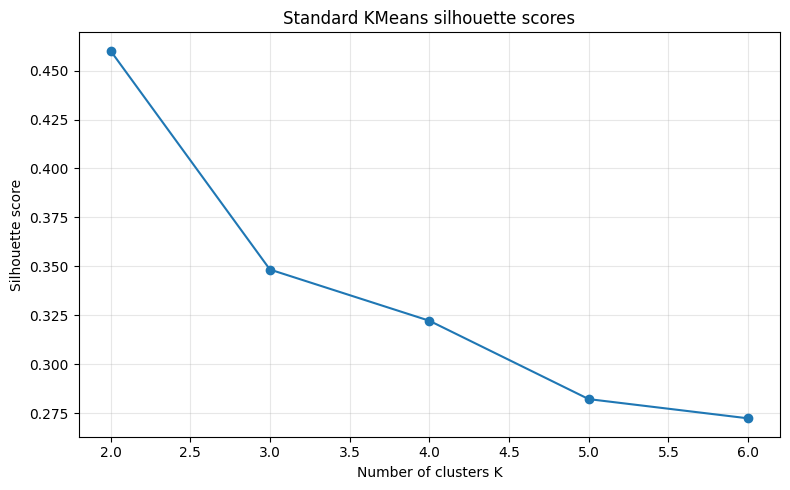

Saved: figures/kmeans_silhouette_scores.png


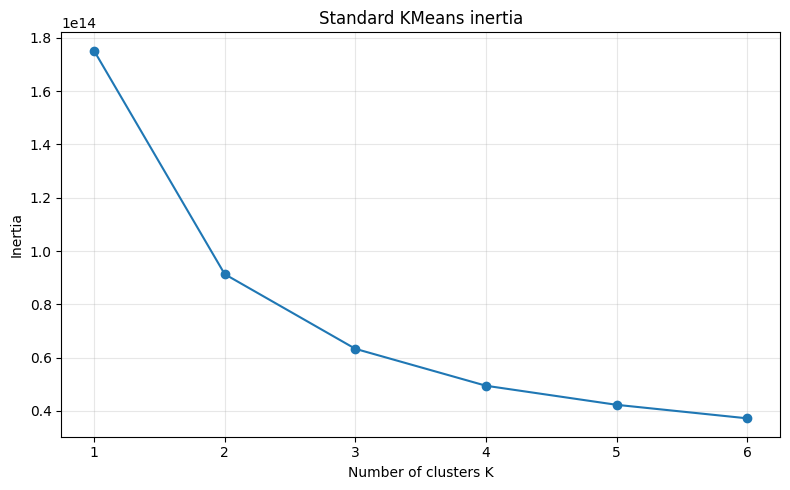

Saved: figures/kmeans_inertia.png
Final K=2 cluster sizes:
final_cluster_K2
0    65613
1    19526
Name: count, dtype: int64


In [9]:
# ============================================================
# 6.1 Standard KMeans clustering
# ============================================================

K_VALUES = [1, 2, 3, 4, 5, 6]
RANDOM_SEED = 42
SILHOUETTE_SAMPLE_SIZE = 5000

kmeans_results = []
kmeans_labels = {}

for K in K_VALUES:
    print(f"Running KMeans for K={K}")

    model = KMeans(
        n_clusters=K,
        random_state=RANDOM_SEED,
        n_init=10,
    )

    labels = model.fit_predict(X_market)
    kmeans_labels[K] = labels

    # Only inertia is defined for K = 1, silhouette and Davies-Bouldin require at least two clusters.
    if K == 1:
        silhouette = np.nan
        davies_bouldin = np.nan
    else:
        silhouette = silhouette_score(
            X_market,
            labels,
            sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X_market)),
            random_state=RANDOM_SEED,
        )

        davies_bouldin = davies_bouldin_score(
            X_market,
            labels,
        )

    kmeans_results.append({
        "K": K,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "inertia": model.inertia_,
    })

kmeans_results = pd.DataFrame(kmeans_results)

print(kmeans_results)

# ============================================================
# 6.2 Plot KMeans silhouette scores
# ============================================================

plot_df = kmeans_results[kmeans_results["K"] > 1]

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["K"],
    plot_df["silhouette_score"],
    marker="o",
)

plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette score")
plt.title("Standard KMeans silhouette scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kmeans_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/kmeans_silhouette_scores.png")

# ============================================================
# 6.3 Plot KMeans inertia
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results["K"],
    kmeans_results["inertia"],
    marker="o",
)

plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Standard KMeans inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kmeans_inertia.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/kmeans_inertia.png")

# ============================================================
# 6.4 Store final K = 2 cluster labels for the remaining analysis
# ============================================================

curve_meta_kmeans = curve_meta.copy()
curve_meta_kmeans["final_cluster_K2"] = kmeans_labels[2]


print("Final K=2 cluster sizes:")
print(curve_meta_kmeans["final_cluster_K2"].value_counts().sort_index())

## 7. PCA visualization

This section projects the final grid-based curve representations into two principal components and colors the observations by their final `K = 2` cluster.

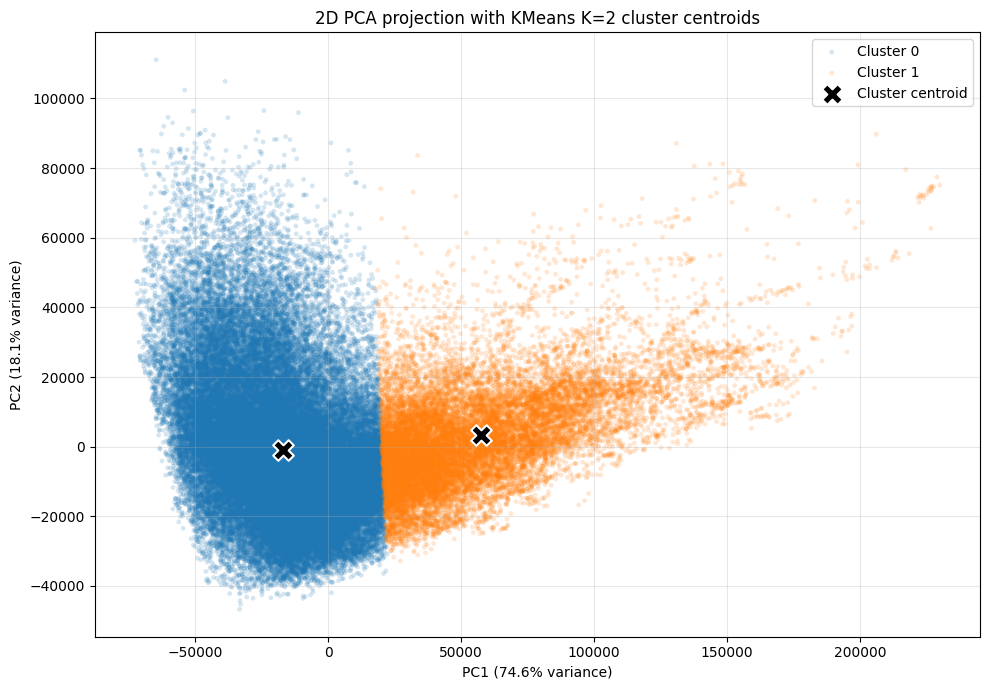

Saved: figures/kmeans_K2_PCA_2D_scatter.png


In [10]:
# ============================================================
# 7.1 Plot PCA projection of grid representations
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_market)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "final_cluster_K2": curve_meta_kmeans["final_cluster_K2"].to_numpy(),
})

cluster_colors = {
    0: "#1f77b4",
    1: "#ff7f0e",
}

plt.figure(figsize=(10, 7))

# Plot observations by final cluster
for cluster_id in sorted(pca_plot_df["final_cluster_K2"].unique()):
    sub = pca_plot_df[pca_plot_df["final_cluster_K2"] == cluster_id]

    plt.scatter(
        sub["PC1"],
        sub["PC2"],
        s=12,             
        alpha=0.18,
        color=cluster_colors.get(cluster_id, "gray"),
        edgecolors="none",
        label=f"Cluster {cluster_id}",
    )

# Compute cluster centroids in PCA space
centroids_pca = (
    pca_plot_df
    .groupby("final_cluster_K2")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

# Plot the centroids on top of the observation cloud
plt.scatter(
    centroids_pca["PC1"],
    centroids_pca["PC2"],
    s=220,
    c="black",
    marker="X",
    edgecolors="white",
    linewidths=1.5,
    label="Cluster centroid",
    zorder=5,
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("2D PCA projection with KMeans K=2 cluster centroids")

plt.legend(frameon=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kmeans_K2_PCA_2D_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/kmeans_K2_PCA_2D_scatter.png")

## 8. Average curves and cluster summary

This section plots the average supply and demand curves for the final two clusters and computes the summary statistics used in the thesis table.

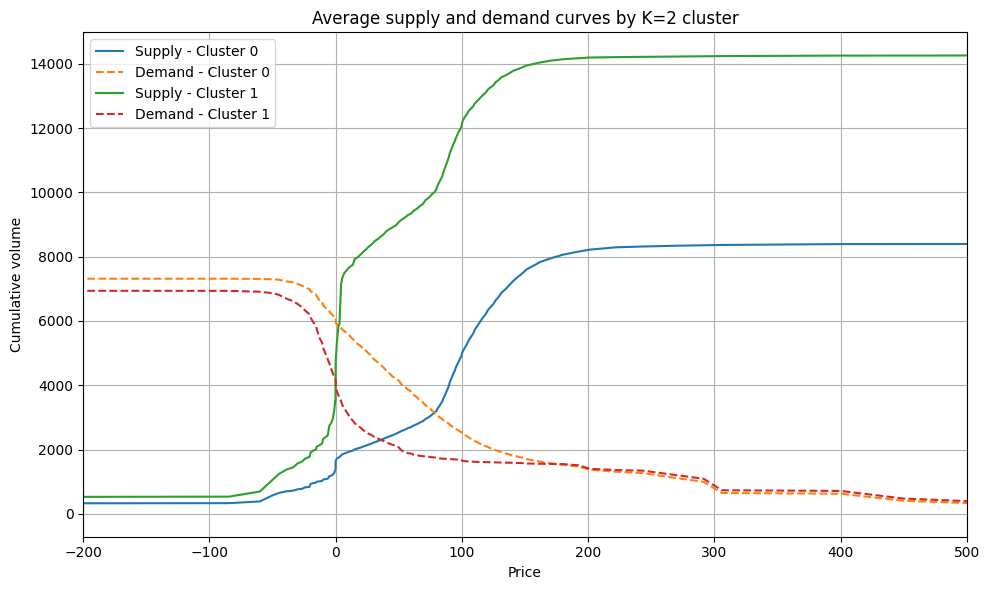

Saved: figures/average_supply_demand_curves_K2.png


In [11]:
# ============================================================
# 8.1 Plot average supply and demand curves for K = 2 clusters
# ============================================================

G = len(grid)

supply_X = X_market[:, :G]
demand_X = X_market[:, G:]

labels = curve_meta_kmeans["final_cluster_K2"].to_numpy()
unique_clusters = np.sort(np.unique(labels))

plt.figure(figsize=(10, 6))

for cluster in unique_clusters:
    idx = labels == cluster

    avg_supply = supply_X[idx].mean(axis=0)
    avg_demand = demand_X[idx].mean(axis=0)

    plt.plot(
        grid,
        avg_supply,
        label=f"Supply - Cluster {cluster}",
    )

    plt.plot(
        grid,
        avg_demand,
        linestyle="--",
        label=f"Demand - Cluster {cluster}",
    )

plt.xlabel("Price")
plt.ylabel("Cumulative volume")
plt.title("Average supply and demand curves by K=2 cluster")
plt.xlim(-200, 500)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("figures/average_supply_demand_curves_K2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/average_supply_demand_curves_K2.png")

In [12]:
# ============================================================
# 8.2 Summary statistics for average curves by cluster
# ============================================================

G = len(grid)

supply_X = X_market[:, :G]
demand_X = X_market[:, G:]

labels = curve_meta_kmeans["final_cluster_K2"].to_numpy()


# Approximate the clearing point by the grid node with the smallest supply-demand gap.
def average_clearing_point(grid, supply_curve, demand_curve):
    """
    Approximate clearing point of average supply and demand curves.
    Uses the grid point where the supply-demand gap is smallest.
    """
    gap = np.abs(supply_curve - demand_curve)
    i = np.argmin(gap)

    clearing_price = grid[i]
    clearing_volume = 0.5 * (supply_curve[i] + demand_curve[i])

    return clearing_price, clearing_volume


summary_rows = []

for cluster in sorted(np.unique(labels)):
    idx = labels == cluster

    avg_supply = supply_X[idx].mean(axis=0)
    avg_demand = demand_X[idx].mean(axis=0)

    clearing_price, clearing_volume = average_clearing_point(
        grid,
        avg_supply,
        avg_demand,
    )

    summary_rows.append({
        "Cluster": cluster,
        "Observations": int(idx.sum()),
        "Share": idx.mean(),
        "Clearing price": clearing_price,
        "Clearing volume": clearing_volume,
        "Total supply": avg_supply[-1],
        "Total demand": avg_demand[0],
    })


average_curve_summary = pd.DataFrame(summary_rows)

display(average_curve_summary)

,Cluster,Observations,Share,Clearing price,Clearing volume,Total supply,Total demand
0,0,65613,0.770657,78.88,3150.088655,8415.901074,7404.893931
1,1,19526,0.229343,0.00,4414.501449,14264.106489,7115.947178


## 9. ENTSO-E data and Random Forest characterization

This section downloads or loads ENTSO-E generation and load data for Spain and Portugal, constructs Iberian system fundamentals, merges them with the cluster metadata, and fits a Random Forest model to characterize the final clusters.

In [16]:
# ============================================================
# Get ENTSO-E data and prepare merged Random Forest dataset
# ============================================================

ENTSOE_CACHE = Path("data/entsoe_fundamentals.csv")
ENTSOE_CACHE.parent.mkdir(parents=True, exist_ok=True)

MARKET_TIMEZONE = "Europe/Madrid"

ENTSOE_API_TOKEN_MANUAL = ""  # only needed if data/entsoe_fundamentals.csv does not exist
ENTSOE_API_TOKEN = ENTSOE_API_TOKEN_MANUAL or os.environ.get("ENTSOE_API_TOKEN", "")

COUNTRIES = ["ES", "PT"]

start = pd.Timestamp("2025-03-20 00:00", tz=MARKET_TIMEZONE)
end = pd.Timestamp("2026-03-20 23:59", tz=MARKET_TIMEZONE)


def flatten_columns(df):
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            " ".join([str(x) for x in col if str(x) != "nan"]).strip()
            for col in df.columns
        ]

    df.columns = [str(c) for c in df.columns]

    return df


def find_columns(df, words):
    words = [w.lower() for w in words]
    return [
        c for c in df.columns
        if any(w in c.lower() for w in words)
    ]


def build_country_fundamentals(client, country):
    print("Downloading ENTSO-E data for:", country)

    generation = client.query_generation(country, start=start, end=end)
    load = client.query_load(country, start=start, end=end)

    generation = flatten_columns(generation)

    if isinstance(load, pd.DataFrame):
        load = load.iloc[:, 0]

    generation.index = pd.to_datetime(generation.index, utc=True)
    load.index = pd.to_datetime(load.index, utc=True)

    df = pd.DataFrame(index=generation.index)

    column_groups = {
        "wind": ["wind"],
        "solar": ["solar"],
        "nuclear": ["nuclear"],
        "hydro": ["hydro"],
        "gas": ["gas"],
        "coal": ["coal", "lignite"],
    }

    for group_name, search_words in column_groups.items():
        cols = find_columns(generation, search_words)

        if cols:
            df[f"{country}_{group_name}"] = generation[cols].sum(axis=1, min_count=1)
        else:
            df[f"{country}_{group_name}"] = np.nan

    # Add total load, keeping all timestamps from generation and load
    load = load.rename(f"{country}_total_load")
    df = df.join(load, how="outer")

    return df.reset_index().rename(columns={"index": "datetime"})


# ------------------------------------------------------------
# 9.1 Download ENTSO-E data once, then reuse the cached CSV in later runs.
# ------------------------------------------------------------

def build_entsoe_fundamentals():
    """
    Downloads ENTSO-E data for Spain and Portugal and builds Iberian variables.
    This is only used if the cached CSV file is not already available.
    """
    if not ENTSOE_API_TOKEN:
        raise ValueError(
            "data/entsoe_fundamentals.csv was not found and no ENTSO-E API token was provided."
        )

    from entsoe import EntsoePandasClient

    client = EntsoePandasClient(api_key=ENTSOE_API_TOKEN)

    country_frames = [
        build_country_fundamentals(client, country)
        for country in COUNTRIES
    ]

    entsoe = country_frames[0]

    for frame in country_frames[1:]:
        entsoe = entsoe.merge(frame, on="datetime", how="outer")

    entsoe = entsoe.sort_values("datetime").drop_duplicates("datetime")

    for var in ["wind", "solar", "nuclear", "hydro", "gas", "coal"]:
        entsoe[f"IB_{var}"] = entsoe[
            [f"{country}_{var}" for country in COUNTRIES]
        ].sum(axis=1, min_count=1)

    entsoe["IB_total_load"] = entsoe[
        [f"{country}_total_load" for country in COUNTRIES]
    ].sum(axis=1, min_count=1)

    entsoe["IB_residual_load"] = (
        entsoe["IB_total_load"]
        - entsoe["IB_wind"]
        - entsoe["IB_solar"]
    )

    entsoe["IB_wind_solar_share"] = (
        (entsoe["IB_wind"] + entsoe["IB_solar"])
        / entsoe["IB_total_load"]
    ).replace([np.inf, -np.inf], np.nan)

    return entsoe

# Load ENTSO-E data from folder or download it

if ENTSOE_CACHE.exists():
    print("Loading ENTSO-E data from:", ENTSOE_CACHE)
    entsoe = pd.read_csv(ENTSOE_CACHE, parse_dates=["datetime"])
else:
    print("ENTSO-E file not found. Downloading from API.")
    entsoe = build_entsoe_fundamentals()
    entsoe.to_csv(ENTSOE_CACHE, index=False)
    print("Saved ENTSO-E data to:", ENTSOE_CACHE)

entsoe["datetime"] = pd.to_datetime(entsoe["datetime"], utc=True)

print("ENTSO-E fundamentals ready:", entsoe.shape)

# ------------------------------------------------------------
# 9.2 Add calendar and delivery-time variables to the cluster metadata.
# ------------------------------------------------------------

meta = curve_meta_kmeans.copy()

def parse_period(period_value):
    s = str(period_value).strip()

    m = re.search(r"H\s*0?(\d+)\s*Q\s*0?(\d+)", s, flags=re.IGNORECASE)

    if m:
        return int(m.group(1)), int(m.group(2))

    p = int(float(s))
    hour = int(np.ceil(p / 4))
    quarter = ((p - 1) % 4) + 1

    return hour, quarter


meta["date_parsed"] = pd.to_datetime(meta["date"], errors="coerce", dayfirst=True)

meta["month"] = meta["date_parsed"].dt.month
meta["month_label"] = meta["date_parsed"].dt.month_name()
meta["weekday"] = meta["date_parsed"].dt.day_name()
meta["weekday_number"] = meta["date_parsed"].dt.weekday
meta["is_weekend"] = meta["weekday_number"].isin([5, 6]).astype(int)
meta["day_type"] = np.where(meta["is_weekend"] == 1, "Weekend", "Weekday")

period_parts = meta["period"].apply(parse_period)

meta["delivery_hour"] = period_parts.apply(lambda x: x[0])
meta["delivery_quarter"] = period_parts.apply(lambda x: x[1])

meta["session"] = pd.to_numeric(meta["session"], errors="coerce")
meta["session_label"] = meta["session"].apply(
    lambda x: f"IDA {int(x)}" if pd.notna(x) else np.nan
)

meta["delivery_time"] = (
    meta["date_parsed"]
    + pd.to_timedelta(meta["delivery_hour"] - 1, unit="h")
    + pd.to_timedelta((meta["delivery_quarter"] - 1) * 15, unit="m")
)

meta["delivery_time"] = (
    meta["delivery_time"]
    .dt.tz_localize(MARKET_TIMEZONE, nonexistent="shift_forward", ambiguous="NaT")
    .dt.tz_convert("UTC")
)


# ------------------------------------------------------------
# 9.3 Merge each market-period observation with the nearest ENTSO-E timestamp.
# ------------------------------------------------------------

left = meta.dropna(subset=["delivery_time"]).copy()
right = entsoe.dropna(subset=["datetime"]).copy()

left["_merge_time"] = left["delivery_time"].dt.tz_localize(None)
right["_merge_time"] = (
    pd.to_datetime(right["datetime"], utc=True)
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

left = left.sort_values("_merge_time")
right = right.sort_values("_merge_time")

merged = pd.merge_asof(
    left,
    right,
    on="_merge_time",
    direction="nearest",
    tolerance=pd.Timedelta("45min"),
)

print("Merged data ready:", merged.shape)
print("Cluster sizes:")
print(merged["final_cluster_K2"].value_counts().sort_index())

Loading ENTSO-E data from: data/entsoe_fundamentals.csv
ENTSO-E fundamentals ready: (35027, 24)
Merged data ready: (85131, 43)
Cluster sizes:
final_cluster_K2
0    65605
1    19526
Name: count, dtype: int64


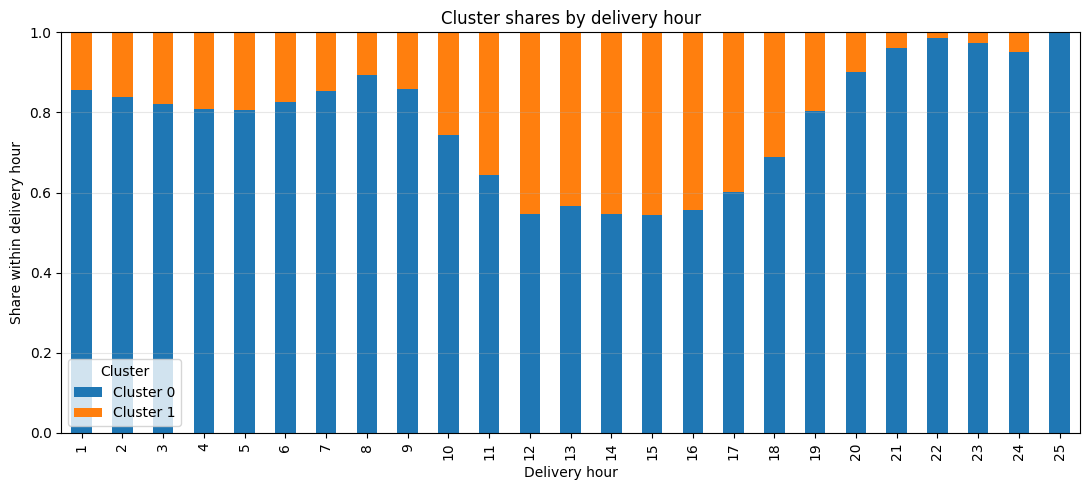

Accuracy: 0.9173
Balanced accuracy: 0.9251
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     16401
           1       0.76      0.94      0.84      4882

    accuracy                           0.92     21283
   macro avg       0.87      0.93      0.89     21283
weighted avg       0.93      0.92      0.92     21283



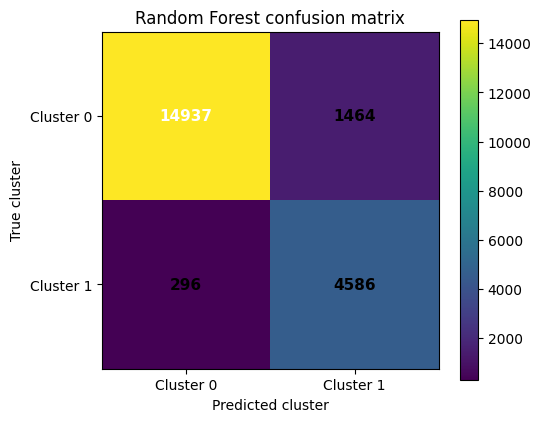

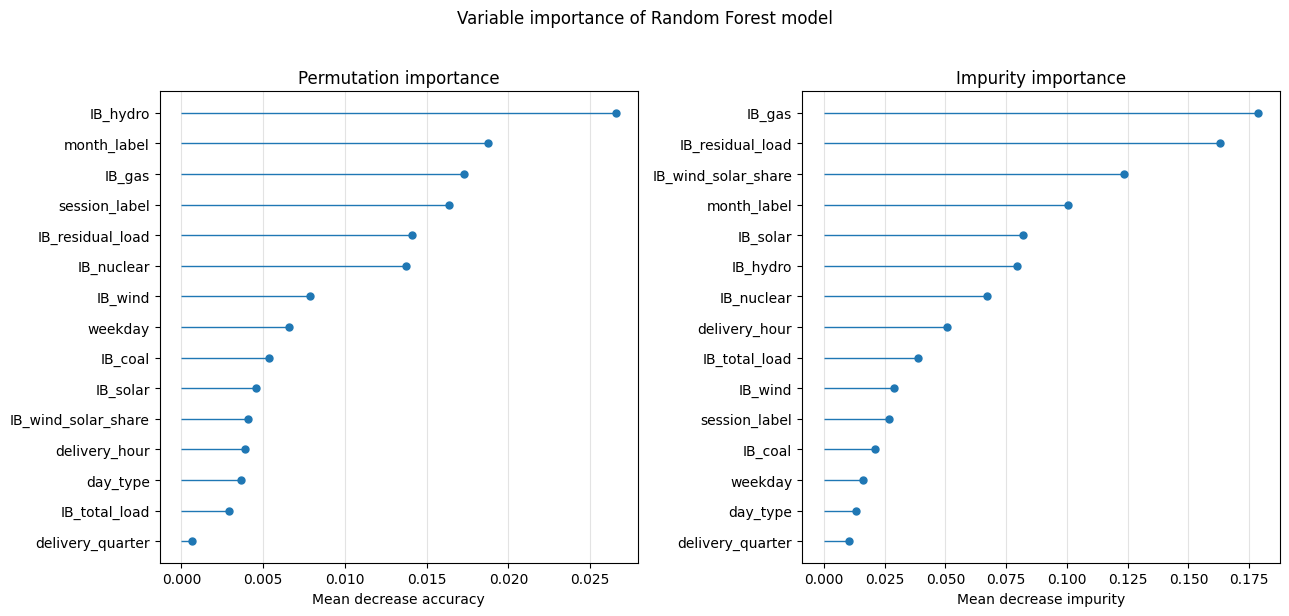

Random Forest plots saved.


In [17]:
# ============================================================
# 9.4 Random Forest model and plots
# ============================================================

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

TEST_SIZE = 0.25
PERMUTATION_SAMPLE_SIZE = 10000

target = "final_cluster_K2"

categorical_features = [
    "session_label",
    "weekday",
    "day_type",
    "month_label",
]

numeric_features = [
    "delivery_hour",
    "delivery_quarter",
    "IB_wind",
    "IB_solar",
    "IB_nuclear",
    "IB_hydro",
    "IB_gas",
    "IB_coal",
    "IB_total_load",
    "IB_residual_load",
    "IB_wind_solar_share",
]


# ------------------------------------------------------------
# 9.5 Plot cluster shares by delivery hour
# ------------------------------------------------------------

shares = pd.crosstab(
    merged["delivery_hour"],
    merged[target],
    normalize="index",
).sort_index()

shares.plot(kind="bar", stacked=True, figsize=(11, 5))

plt.xlabel("Delivery hour")
plt.ylabel("Share within delivery hour")
plt.title("Cluster shares by delivery hour")
plt.legend(title="Cluster", labels=[f"Cluster {c}" for c in shares.columns])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "cluster_shares_by_delivery_hour.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 9.6 Fit Random Forest classifier
# ------------------------------------------------------------

model_df = merged[categorical_features + numeric_features + [target]].copy()
model_df = model_df.dropna(subset=[target])

X_rf = model_df[categorical_features + numeric_features]
y_rf = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_rf,
    y_rf,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_rf,
)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", onehot),
            ]),
            categorical_features,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
    ]
)

rf_model = Pipeline([
    ("preprocess", preprocess),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_SEED,
            class_weight="balanced",
            min_samples_leaf=20,
            criterion="gini",
            n_jobs=-1,
        ),
    ),
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# 9.7 Plot confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
classes = sorted(y_rf.unique())

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, interpolation="nearest")
plt.title("Random Forest confusion matrix")
plt.xlabel("Predicted cluster")
plt.ylabel("True cluster")
plt.colorbar()

plt.xticks(np.arange(len(classes)), [f"Cluster {c}" for c in classes])
plt.yticks(np.arange(len(classes)), [f"Cluster {c}" for c in classes])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=11,
            fontweight="bold",
        )

plt.tight_layout()
plt.savefig(FIG_DIR / "rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 9.8 Compute feature importances
# ------------------------------------------------------------

encoded_features = rf_model.named_steps["preprocess"].get_feature_names_out()
raw_importance = rf_model.named_steps["rf"].feature_importances_

importance_raw = pd.DataFrame({
    "encoded_feature": encoded_features,
    "importance": raw_importance,
})

def original_feature_name(encoded_feature):
    f = str(encoded_feature)

    if f.startswith("num__"):
        return f.replace("num__", "")

    if f.startswith("cat__"):
        f = f.replace("cat__", "")

        for col in categorical_features:
            if f.startswith(col + "_"):
                return col

    return f


gini_importance = (
    importance_raw
    .assign(feature=lambda d: d["encoded_feature"].apply(original_feature_name))
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

if len(X_test) > PERMUTATION_SAMPLE_SIZE:
    X_perm = X_test.sample(PERMUTATION_SAMPLE_SIZE, random_state=RANDOM_SEED)
    y_perm = y_test.loc[X_perm.index]
else:
    X_perm = X_test.copy()
    y_perm = y_test.copy()

perm_result = permutation_importance(
    rf_model,
    X_perm,
    y_perm,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring="accuracy",
)

perm_importance = pd.DataFrame({
    "feature": X_perm.columns,
    "mean_decrease_accuracy": perm_result.importances_mean,
}).sort_values("mean_decrease_accuracy", ascending=False)


# ------------------------------------------------------------
# 9.9 Plot combined variable importance
# ------------------------------------------------------------

left_df = perm_importance.sort_values("mean_decrease_accuracy", ascending=True)
right_df = gini_importance.sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

y_left = np.arange(len(left_df))
axes[0].hlines(y=y_left, xmin=0, xmax=left_df["mean_decrease_accuracy"], linewidth=1)
axes[0].plot(left_df["mean_decrease_accuracy"], y_left, "o", markersize=5)
axes[0].set_yticks(y_left)
axes[0].set_yticklabels(left_df["feature"])
axes[0].set_xlabel("Mean decrease accuracy")
axes[0].set_title("Permutation importance")
axes[0].grid(axis="x", alpha=0.35)

y_right = np.arange(len(right_df))
axes[1].hlines(y=y_right, xmin=0, xmax=right_df["importance"], linewidth=1)
axes[1].plot(right_df["importance"], y_right, "o", markersize=5)
axes[1].set_yticks(y_right)
axes[1].set_yticklabels(right_df["feature"])
axes[1].set_xlabel("Mean decrease impurity")
axes[1].set_title("Impurity importance")
axes[1].grid(axis="x", alpha=0.35)

fig.suptitle("Variable importance of Random Forest model", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "rf_variable_importance_combined.png", dpi=300, bbox_inches="tight")
plt.show()

print("Random Forest plots saved.")